# Training a Conditional VAE on PBMC 3k with Negative Binomial Decoder

This notebook demonstrates:
1. Preprocessing PBMC 3k data (preserving raw counts)
2. Training a cVAE with NB decoder on real scRNA-seq data
3. Visualizing the latent space (UMAP)
4. Evaluating via downstream cell type classification

**Key principle**: We use raw counts + library size, not normalized data.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader

import scanpy as sc

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check device
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


## 1. Load and Preprocess PBMC 3k

We download the PBMC 3k dataset and perform minimal preprocessing:
- Filter low-quality cells and genes
- Compute library size (total counts per cell)
- Select highly variable genes
- **Keep raw counts** (no normalization!)

In [2]:
# Download PBMC 3k
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
print(f"Raw data: {adata.n_obs} cells, {adata.n_vars} genes")

Raw data: 2700 cells, 32738 genes


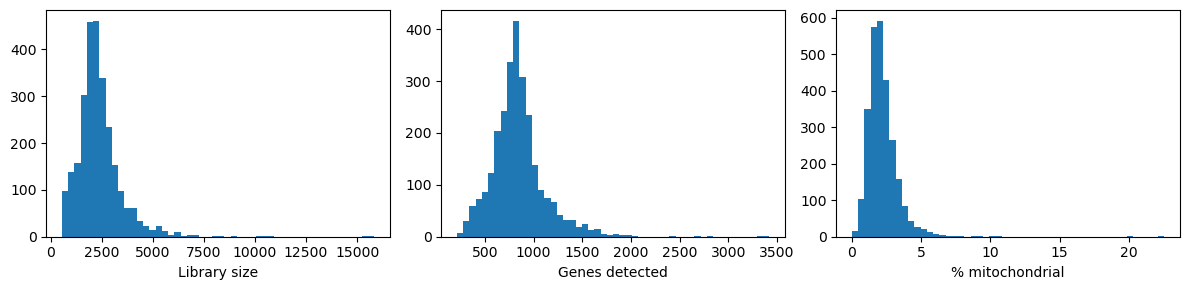

In [3]:
# QC metrics
adata.obs["library_size"] = np.array(adata.X.sum(axis=1)).ravel()
adata.obs["n_genes"] = np.array((adata.X > 0).sum(axis=1)).ravel()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

# Plot QC
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(adata.obs["library_size"], bins=50)
axes[0].set_xlabel("Library size")
axes[1].hist(adata.obs["n_genes"], bins=50)
axes[1].set_xlabel("Genes detected")
axes[2].hist(adata.obs["pct_counts_mt"], bins=50)
axes[2].set_xlabel("% mitochondrial")
plt.tight_layout()
plt.show()

In [4]:
# Filter cells and genes
sc.pp.filter_cells(adata, min_genes=200)
adata = adata[adata.obs.pct_counts_mt < 20].copy()
sc.pp.filter_genes(adata, min_cells=3)
print(f"After filtering: {adata.n_obs} cells, {adata.n_vars} genes")

After filtering: 2698 cells, 13714 genes


In [5]:
# Store raw counts BEFORE any normalization
adata.layers["counts"] = adata.X.copy()

# Recompute library size after filtering
adata.obs["library_size"] = np.array(adata.X.sum(axis=1)).ravel()

# HVG selection (uses temporary normalization internally)
adata_norm = adata.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)
sc.pp.highly_variable_genes(adata_norm, n_top_genes=2000)
adata.var["highly_variable"] = adata_norm.var["highly_variable"]

# Subset to HVGs
adata = adata[:, adata.var.highly_variable].copy()
print(f"After HVG selection: {adata.n_obs} cells, {adata.n_vars} genes")

After HVG selection: 2698 cells, 2000 genes


In [6]:
# Get cell type annotations (from processed version)
# PBMC 3k has standard Louvain clusters that map to known cell types
adata_processed = sc.datasets.pbmc3k_processed()

# Match cells by barcode
common_cells = adata.obs_names.intersection(adata_processed.obs_names)
adata = adata[common_cells].copy()
adata.obs["cell_type"] = adata_processed.obs.loc[common_cells, "louvain"].astype("category")

print(f"Final dataset: {adata.n_obs} cells, {adata.n_vars} genes")
print(f"Cell types: {adata.obs.cell_type.value_counts().to_dict()}")

Final dataset: 2638 cells, 2000 genes
Cell types: {'CD4 T cells': 1144, 'CD14+ Monocytes': 480, 'B cells': 342, 'CD8 T cells': 316, 'NK cells': 154, 'FCGR3A+ Monocytes': 150, 'Dendritic cells': 37, 'Megakaryocytes': 15}


## 2. Create PyTorch Dataset and DataLoaders

In [7]:
from genailab.data.sc_dataset import SingleCellDataset, collate_sc_batch
from genailab.data.loaders import split_dataset

# Create dataset with raw counts and cell type as condition
dataset = SingleCellDataset(
    adata,
    layer="counts",
    condition_keys=["cell_type"],
)

print(f"Dataset: {len(dataset)} cells, {dataset.n_genes} genes")
print(f"Conditions: {dataset.n_conditions}")
print(f"Library size stats: {dataset.get_library_size_stats()}")

Dataset: 2638 cells, 2000 genes
Conditions: {'cell_type': 8}
Library size stats: {'mean': 2371.069091796875, 'std': 989.9710693359375, 'median': 2213.0, 'min': 556.0, 'max': 8875.0}


In [8]:
# Split into train/val
train_ds, val_ds = split_dataset(dataset, val_frac=0.15, seed=42)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

# Create data loaders
train_loader = DataLoader(
    train_ds, 
    batch_size=128, 
    shuffle=True, 
    collate_fn=collate_sc_batch,
    num_workers=0,
)
val_loader = DataLoader(
    val_ds, 
    batch_size=256, 
    shuffle=False, 
    collate_fn=collate_sc_batch,
    num_workers=0,
)

Train: 2243, Val: 395


In [9]:
# Inspect a batch
batch = next(iter(train_loader))
print(f"Batch keys: {batch.keys()}")
print(f"x shape: {batch['x'].shape}")
print(f"library_size shape: {batch['library_size'].shape}")
print(f"cond keys: {batch['cond'].keys()}")
print(f"cell_type shape: {batch['cond']['cell_type'].shape}")

Batch keys: dict_keys(['x', 'library_size', 'cond'])
x shape: torch.Size([128, 2000])
library_size shape: torch.Size([128])
cond keys: dict_keys(['cell_type'])
cell_type shape: torch.Size([128])


## 3. Create and Train the cVAE with NB Decoder

In [10]:
from genailab.model.conditioning import ConditionSpec, ConditionEncoder
from genailab.model.vae import CVAE_NB
from genailab.objectives.losses import elbo_loss_nb

# Create condition encoder
spec = ConditionSpec(
    n_cats={"cell_type": dataset.n_conditions["cell_type"]},
    emb_dim=32,
    out_dim=64,
)
cond_encoder = ConditionEncoder(spec)

# Create model
model = CVAE_NB(
    n_genes=dataset.n_genes,
    z_dim=32,
    cond_encoder=cond_encoder,
    hidden=256,
    n_layers=2,
    dropout=0.1,
)
model = model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,224,032


In [11]:
def train_epoch(model, loader, optimizer, device, beta=1.0):
    """Train for one epoch."""
    model.train()
    total_loss, total_recon, total_kl = 0, 0, 0
    
    for batch in loader:
        x = batch["x"].to(device)
        library_size = batch["library_size"].to(device)
        cond = {k: v.to(device) for k, v in batch["cond"].items()}
        
        # Forward pass
        out = model(x, cond, library_size)
        
        # Compute loss
        loss, parts = elbo_loss_nb(
            x, out["mu"], out["theta"],
            out["enc_mu"], out["enc_logvar"],
            beta=beta,
        )
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        total_loss += loss.item()
        total_recon += parts["recon"].item()
        total_kl += parts["kl"].item()
    
    n = len(loader)
    return total_loss / n, total_recon / n, total_kl / n


@torch.no_grad()
def eval_epoch(model, loader, device, beta=1.0):
    """Evaluate for one epoch."""
    model.eval()
    total_loss, total_recon, total_kl = 0, 0, 0
    
    for batch in loader:
        x = batch["x"].to(device)
        library_size = batch["library_size"].to(device)
        cond = {k: v.to(device) for k, v in batch["cond"].items()}
        
        out = model(x, cond, library_size)
        loss, parts = elbo_loss_nb(
            x, out["mu"], out["theta"],
            out["enc_mu"], out["enc_logvar"],
            beta=beta,
        )
        
        total_loss += loss.item()
        total_recon += parts["recon"].item()
        total_kl += parts["kl"].item()
    
    n = len(loader)
    return total_loss / n, total_recon / n, total_kl / n

In [12]:
# Training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

n_epochs = 50
beta = 0.5  # Start with lower beta to avoid posterior collapse

history = {"train_loss": [], "val_loss": [], "train_recon": [], "val_recon": [], "train_kl": [], "val_kl": []}
best_val_loss = float("inf")

for epoch in range(1, n_epochs + 1):
    # Train
    train_loss, train_recon, train_kl = train_epoch(model, train_loader, optimizer, device, beta=beta)
    
    # Validate
    val_loss, val_recon, val_kl = eval_epoch(model, val_loader, device, beta=beta)
    
    # Record
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_recon"].append(train_recon)
    history["val_recon"].append(val_recon)
    history["train_kl"].append(train_kl)
    history["val_kl"].append(val_kl)
    
    # LR scheduler
    scheduler.step(val_loss)
    
    # Save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_cvae_nb.pt")
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train: loss={train_loss:.4f} recon={train_recon:.4f} kl={train_kl:.4f} | Val: loss={val_loss:.4f}")

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch   1 | Train: loss=0.8649 recon=0.8585 kl=0.0128 | Val: loss=0.5827
Epoch   5 | Train: loss=0.3325 recon=0.3323 kl=0.0003 | Val: loss=0.3383
Epoch  10 | Train: loss=0.3192 recon=0.3192 kl=0.0001 | Val: loss=0.3306
Epoch  15 | Train: loss=0.3136 recon=0.3135 kl=0.0001 | Val: loss=0.3265
Epoch  20 | Train: loss=0.3105 recon=0.3104 kl=0.0001 | Val: loss=0.3249
Epoch  25 | Train: loss=0.3086 recon=0.3086 kl=0.0001 | Val: loss=0.3241
Epoch  30 | Train: loss=0.3072 recon=0.3071 kl=0.0000 | Val: loss=0.3235
Epoch  35 | Train: loss=0.3060 recon=0.3059 kl=0.0000 | Val: loss=0.3232
Epoch  40 | Train: loss=0.3048 recon=0.3048 kl=0.0000 | Val: loss=0.3227
Epoch  45 | Train: loss=0.3049 recon=0.3049 kl=0.0000 | Val: loss=0.3227
Epoch  50 | Train: loss=0.3042 recon=0.3042 kl=0.0000 | Val: loss=0.3220

Best validation loss: 0.3220


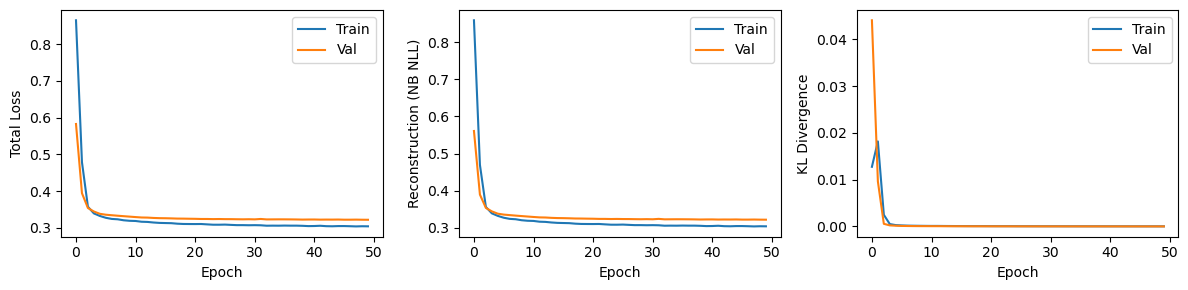

In [13]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Total Loss")
axes[0].legend()

axes[1].plot(history["train_recon"], label="Train")
axes[1].plot(history["val_recon"], label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Reconstruction (NB NLL)")
axes[1].legend()

axes[2].plot(history["train_kl"], label="Train")
axes[2].plot(history["val_kl"], label="Val")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("KL Divergence")
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. Extract Latent Representations and Visualize

In [14]:
# Load best model
model.load_state_dict(torch.load("best_cvae_nb.pt", map_location=device))
model.eval()

# Extract latents for all cells
all_loader = DataLoader(
    dataset, 
    batch_size=256, 
    shuffle=False, 
    collate_fn=collate_sc_batch,
)

latents = []
cell_types = []

with torch.no_grad():
    for batch in all_loader:
        x = batch["x"].to(device)
        cond = {k: v.to(device) for k, v in batch["cond"].items()}
        
        mu, _ = model.encode(x, cond)
        latents.append(mu.cpu().numpy())
        cell_types.append(batch["cond"]["cell_type"].numpy())

latents = np.concatenate(latents, axis=0)
cell_types = np.concatenate(cell_types, axis=0)

print(f"Latent shape: {latents.shape}")

Latent shape: (2638, 32)


/Users/pleiadian53/miniforge3-new/envs/genailab/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


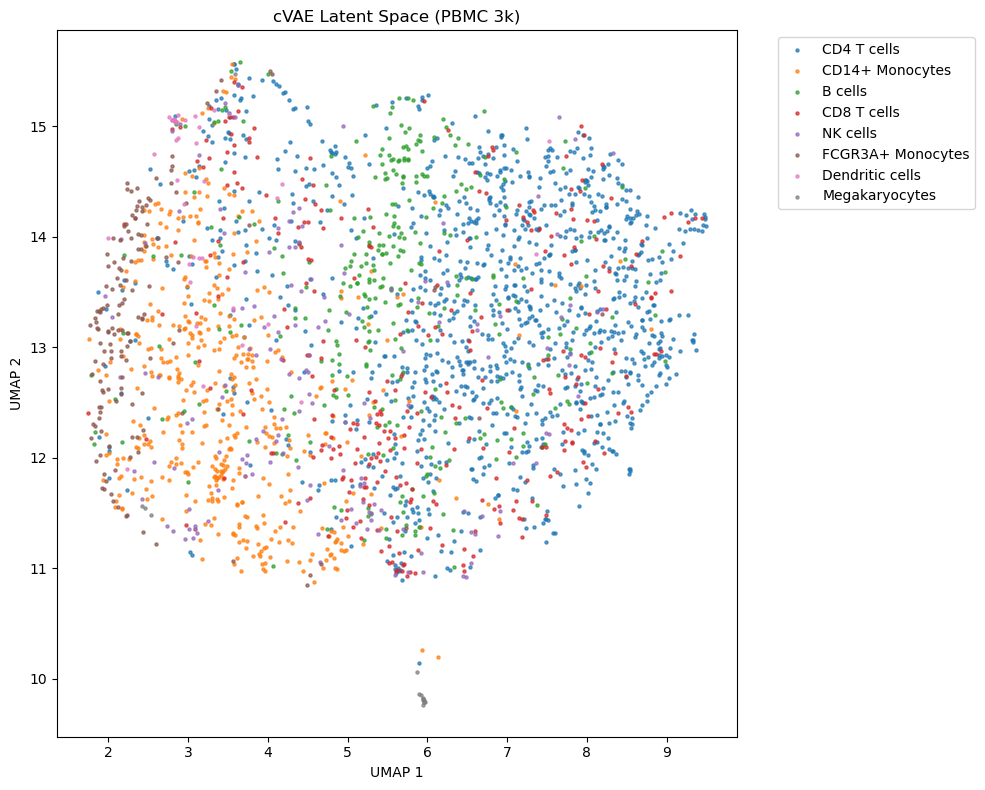

In [15]:
# UMAP visualization
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(latents)

# Get cell type names
cell_type_names = adata.obs["cell_type"].cat.categories.tolist()
cell_type_labels = [cell_type_names[i] for i in cell_types]

# Plot
plt.figure(figsize=(10, 8))
for i, ct in enumerate(cell_type_names):
    mask = np.array(cell_type_labels) == ct
    plt.scatter(embedding[mask, 0], embedding[mask, 1], label=ct, s=5, alpha=0.7)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("cVAE Latent Space (PBMC 3k)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Downstream Evaluation: Cell Type Classification

To evaluate the quality of the learned representations, we train a simple classifier on the latent space.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split latents
X_train, X_test, y_train, y_test = train_test_split(
    latents, cell_types, test_size=0.2, random_state=42, stratify=cell_types
)

# Train logistic regression
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Cell type classification accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=cell_type_names))

Cell type classification accuracy: 0.4337

Classification Report:
                   precision    recall  f1-score   support

      CD4 T cells       0.43      1.00      0.61       229
  CD14+ Monocytes       0.00      0.00      0.00        96
          B cells       0.00      0.00      0.00        69
      CD8 T cells       0.00      0.00      0.00        63
         NK cells       0.00      0.00      0.00        31
FCGR3A+ Monocytes       0.00      0.00      0.00        30
  Dendritic cells       0.00      0.00      0.00         7
   Megakaryocytes       0.00      0.00      0.00         3

         accuracy                           0.43       528
        macro avg       0.05      0.12      0.08       528
     weighted avg       0.19      0.43      0.26       528



/Users/pleiadian53/miniforge3-new/envs/genailab/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pleiadian53/miniforge3-new/envs/genailab/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pleiadian53/miniforge3-new/envs/genailab/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [17]:
# Compare with PCA baseline
from sklearn.decomposition import PCA

# Get raw counts for comparison
X_counts = dataset.X

# Log-normalize for PCA (standard practice)
X_norm = np.log1p(X_counts / X_counts.sum(axis=1, keepdims=True) * 1e4)

# PCA
pca = PCA(n_components=32)
X_pca = pca.fit_transform(X_norm)

# Split and train
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, cell_types, test_size=0.2, random_state=42, stratify=cell_types
)

clf_pca = LogisticRegression(max_iter=1000, random_state=42)
clf_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = clf_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

print(f"\nComparison:")
print(f"  cVAE latent accuracy: {accuracy:.4f}")
print(f"  PCA baseline accuracy: {accuracy_pca:.4f}")


Comparison:
  cVAE latent accuracy: 0.4337
  PCA baseline accuracy: 0.9451


## 6. Summary

This notebook demonstrated:

1. **Proper preprocessing** for generative models: raw counts + library size
2. **Training a cVAE with NB decoder** on real scRNA-seq data
3. **Latent space visualization** showing cell type separation
4. **Downstream evaluation** via cell type classification

### Next Steps

- Try ZINB decoder for sparser data
- Experiment with β-VAE for disentanglement
- Add more conditions (batch, donor)
- Implement counterfactual generation